<a href="https://colab.research.google.com/github/Lyv-ux/DI_Bootcamp/blob/main/DailyChallenge_Hands_on_image_Transformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files


In [ ]:
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d olgabelitskaya/flower-color-images

Saving Flower Color Images Dataset.zip to Flower Color Images Dataset.zip
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/olgabelitskaya/flower-color-images
License(s): other
100% 50.1M/50.1M [00:00<00:00, 103MB/s]



In [ ]:
!unzip flower-color-images.zip


Archive:  flower-color-images.zip
  inflating: FlowerColorImages.h5    
  inflating: flower_images/flower_images/0001.png  
  inflating: flower_images/flower_images/0002.png  
  inflating: flower_images/flower_images/0003.png  
  inflating: flower_images/flower_images/0004.png  
  inflating: flower_images/flower_images/0005.png  
  inflating: flower_images/flower_images/0006.png  
  inflating: flower_images/flower_images/0007.png  
  inflating: flower_images/flower_images/0008.png  
  inflating: flower_images/flower_images/0009.png  
  inflating: flower_images/flower_images/0010.png  
  inflating: flower_images/flower_images/0011.png  
  inflating: flower_images/flower_images/0012.png  
  inflating: flower_images/flower_images/0013.png  
  inflating: flower_images/flower_images/0014.png  
  inflating: flower_images/flower_images/0015.png  
  inflating: flower_images/flower_images/0016.png  
  inflating: flower_images/flower_images/0017.png  
  inflating: flower_images/flower_images/001

In [ ]:
!pip install tensorflow
! pip install keras
! pip install pillow

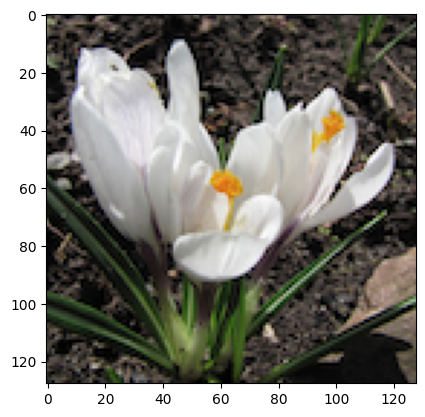

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
# Load an image using PIL
image_path = 'flowers/flowers/19_009.png'
original_image = Image.open(image_path)

# Display the original image using matplotlib
plt.imshow(original_image)

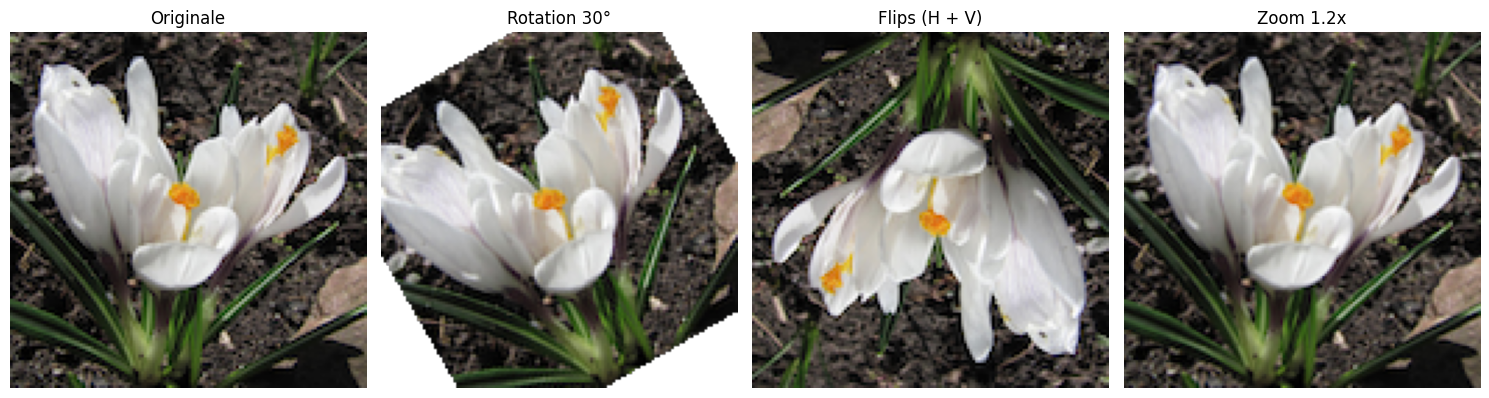

In [10]:
from scipy.ndimage import rotate
from PIL import Image, ImageOps
import numpy as np


 # Rotation
 #On convertit l'image en tableau de chiffres car Scipy ne comprend pas les ima-
 #mais les chiffres. Après traitement, on ft le traitement inverse(array->img)
def rotate_image_30_degrees(image):
    image_array = np.array(image)
    rotated_array = rotate(image_array, angle=30, reshape=False)
    return Image.fromarray(rotated_array)

# Zoom
#Pas besoin de convertir en array ici car PIL sait bien zoomer et comprend les
#images.
def zoom_image(image, scale=1.2):
    width, height = image.size
    return image.resize((int(width * scale), int(height * scale)))

# --- MISE EN APPLICATION DES FONCTIONS CRéES---
image_rotated = rotate_image_30_degrees(original_image)
image_flipped = ImageOps.flip(ImageOps.mirror(original_image)) # Miroir + Flip
image_zoomed = zoom_image(original_image, 1.2)

# --- VISUALISATION AVEC MATPLOTLIB ---
# On fixe le nombre de grilles avec leurs tailles
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

# On affiche ce qui sera inscrit pour chaque grille, retire les graduations inu-
#tiles et place chaque image dans une grille grâce à leurs indexs

axes[0].imshow(original_image)
axes[0].set_title("Originale")
axes[0].axis('off')

axes[1].imshow(image_rotated)
axes[1].set_title("Rotation 30°")
axes[1].axis('off')

axes[2].imshow(image_flipped)
axes[2].set_title("Flips (H + V)")
axes[2].axis('off')

axes[3].imshow(image_zoomed)
axes[3].set_title("Zoom 1.2x")
axes[3].axis('off')

#Resserre proprement les images et les cases pour qu'elles ne se croisent pas
#entre elles
plt.tight_layout()
#Affiche
plt.show()